In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
file_path='/content/drive/MyDrive/dati/mCSM-PPI2.csv'
try:
    df_drive = pd.read_csv(file_path, sep = "\t")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
df_drive

,pdb,mutation,actual,mcsm_ppi2_prediction,sampling_fold
0,1E50,DA66A,0.402,-1.583757,1
1,1E50,KA144M,-0.320,-0.225983,1
2,1E50,MA106A,-1.320,-1.015493,1
3,1E50,NA69A,-0.678,-0.451897,1
4,1E50,NA109A,-2.433,-1.724910,1
...,...,...,...,...,...
4164,5XCO,PB6A,-1.079,-1.703510,10
4165,5XCO,SB10A,-1.286,-0.669203,10
4166,5XCO,VB14A,0.000,-0.602697,10
4167,5XCO,YB11A,-1.900,-1.171687,10


In [7]:
pdb_occurrences = df_drive['pdb'].value_counts().to_dict()
print(pdb_occurrences)
print(len(pdb_occurrences))

{'3BT1': 240, '3SGB': 191, '1CHO': 191, '1R0R': 191, '1PPF': 190, '1A22': 142, '1DAN': 89, '1AO7': 86, '3S9D': 81, '3HFM': 71, '1JTG': 58, '1GC1': 54, '1MHP': 50, '1OGA': 48, '1C4Z': 48, '1VFB': 48, '1EMV': 46, '1BP3': 45, '2JEL': 44, '1JRH': 43, '3NGB': 41, '1MI5': 39, '1LFD': 38, '4RS1': 36, '1IAR': 36, '1JTD': 36, '3C60': 35, '3BN9': 35, '4NKQ': 34, '1A4Y': 32, '1CBW': 31, '2FTL': 31, '4G0N': 30, '2NYY': 30, '1BRS': 30, '2WPT': 29, '2AK4': 29, '3SE8': 28, '2G2U': 27, '3NPS': 27, '1KTZ': 27, '3SE4': 27, '1EAW': 27, '4P23': 26, '2BNR': 26, '4P5T': 26, '4PWX': 25, '3SE9': 25, '1DVF': 25, '3QHY': 25, '3QIB': 25, '1DQJ': 21, '3SZK': 21, '1B41': 20, '1FSS': 20, '1K8R': 19, '2NZ9': 19, '1FFW': 19, '3M62': 18, '1XD3': 18, '1FC2': 18, '5C6T': 18, '1Z7X': 17, '3SE3': 17, '1TM1': 17, '1E50': 16, '1YY9': 16, '1AK4': 16, '2J0T': 16, '3QDJ': 15, '1C1Y': 15, '5M2O': 14, '3QDG': 14, '1KNE': 13, '5F4E': 13, '3BK3': 13, '1N8Z': 12, '4I77': 12, '1F47': 12, '4OZG': 12, '1GUA': 12, '2BDN': 12, '5XCO': 1

In [9]:
with open("pdb_mcsmppi2.txt", "w") as writer:
  for key in pdb_occurrences:
    writer.write(key+"\n")

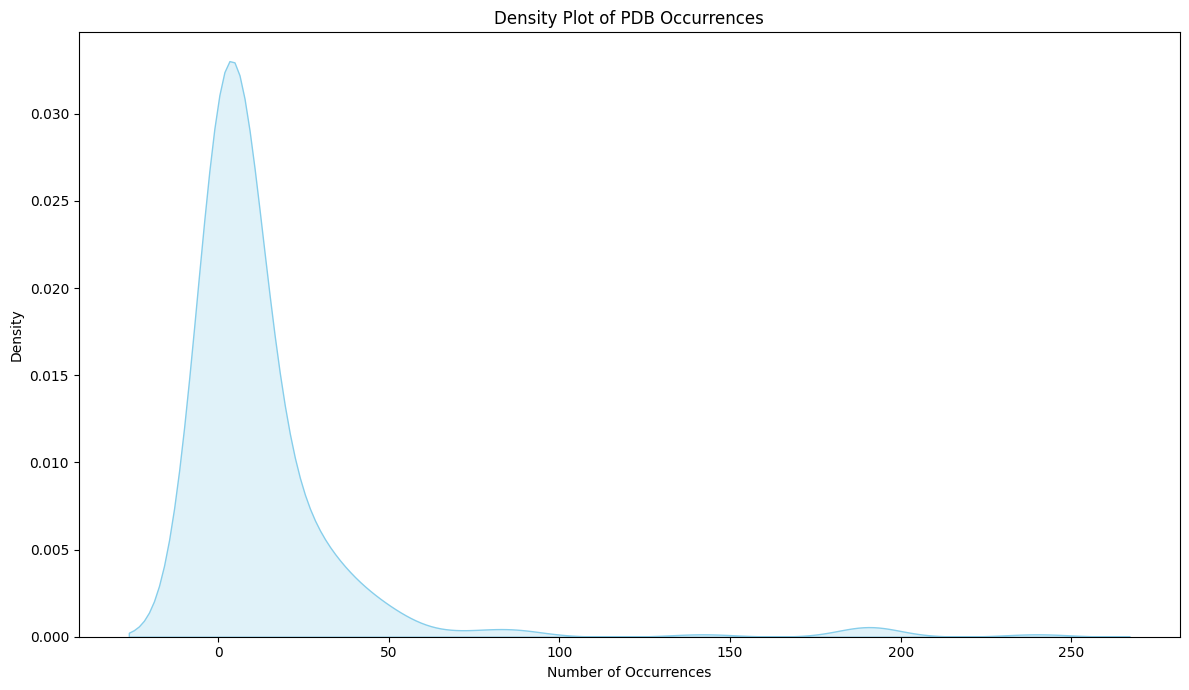

In [10]:
pdb_counts_series = pd.Series(pdb_occurrences)

plt.figure(figsize=(12, 7))
sns.kdeplot(pdb_counts_series.values, fill=True, color='skyblue')
plt.title('Density Plot of PDB Occurrences')
plt.xlabel('Number of Occurrences')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### 8 PDB IDs were not mapped in Uniprot.

In [11]:
filepath = '/content/drive/MyDrive/dati/mcsm_mapping.tsv'
try:
    df_mapping = pd.read_table(filepath)
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [12]:
from_entry_dict = df_mapping.groupby('From')['Entry'].apply(list).to_dict()
print(from_entry_dict)

{'1A22': ['P01241', 'P10912'], '1A4Y': ['P03950', 'P13489'], '1ACB': ['P01051', 'P00766'], '1AHW': ['P01837', 'P01868', 'P13726'], '1AK4': ['P12497', 'P62937'], '1AO7': ['P14079', 'A0A075B6T6', 'A0A0K0K1A5', 'A0A5B9', 'P01848', 'P01850', 'P04439', 'P61769'], '1B2S': ['P00648', 'P11540'], '1B2U': ['P00648', 'P11540'], '1B3S': ['P00648', 'P11540'], '1B41': ['P0C1Z0', 'P22303'], '1BD2': ['P14079', 'P0C213', 'A0A0K0K1A5', 'A0A5B9', 'P01848', 'P04437', 'P04439', 'P61769'], '1BJ1': ['P15692'], '1BP3': ['P01241', 'P16471'], '1BRS': ['P00648', 'P11540'], '1C1Y': ['P04049', 'P62834'], '1C4Z': ['P68036', 'Q05086'], '1CBW': ['P00766', 'P00767', 'P00974'], '1CHO': ['P68390', 'P00766'], '1CSE': ['P00780', 'P01051'], '1CSO': ['P00777', 'P68390'], '1CT0': ['P00777', 'P68390'], '1CT2': ['P00777', 'P68390'], '1CT4': ['P00777', 'P68390'], '1CZ8': ['P15692'], '1DAN': ['P08709', 'P13726'], '1DQJ': ['P01837', 'P01865', 'P00698'], '1DVF': ['P01635', 'P01646', 'P01820'], '1E50': ['Q01196', 'Q13951'], '1E96':

In [14]:
df_drive['uniprot'] = df_drive['pdb'].map(from_entry_dict)
display(df_drive.head())

,pdb,mutation,actual,mcsm_ppi2_prediction,sampling_fold,uniprot
0,1E50,DA66A,0.402,-1.583757,1,"[Q01196, Q13951]"
1,1E50,KA144M,-0.320,-0.225983,1,"[Q01196, Q13951]"
2,1E50,MA106A,-1.320,-1.015493,1,"[Q01196, Q13951]"
3,1E50,NA69A,-0.678,-0.451897,1,"[Q01196, Q13951]"
4,1E50,NA109A,-2.433,-1.724910,1,"[Q01196, Q13951]"


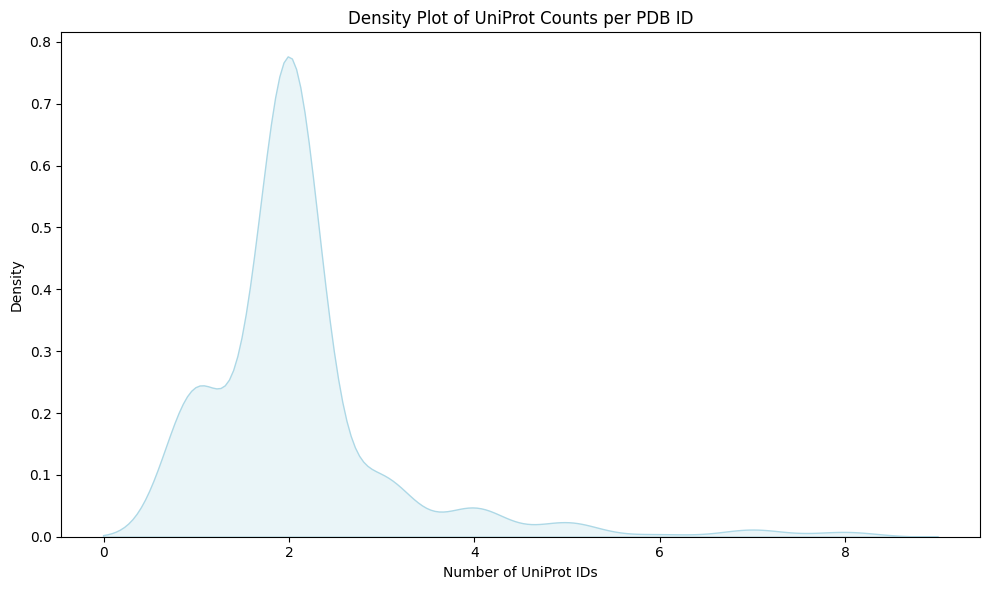

In [15]:
proteins_compl = {}
for key in from_entry_dict:
  proteins_compl[key]=len(from_entry_dict[key])

uniprot_counts_series = pd.Series(proteins_compl)

plt.figure(figsize=(10, 6))
sns.kdeplot(uniprot_counts_series.values, fill=True, color='lightblue')
plt.title('Density Plot of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

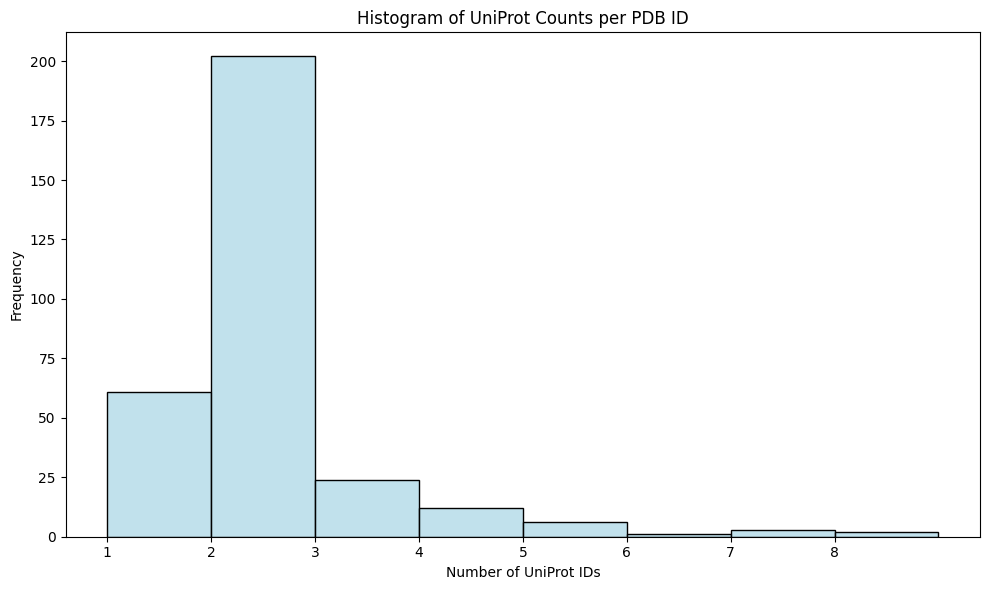

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(uniprot_counts_series.values, bins=range(1, max(uniprot_counts_series.values) + 2), kde=False, color='lightblue', edgecolor='black')
plt.title('Histogram of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Frequency')
plt.xticks(range(1, max(uniprot_counts_series.values) + 1))
plt.tight_layout()
plt.show()

In [17]:
min_uniprot_count = min(proteins_compl.values())
print(f"The minimum number of UniProt IDs associated with a PDB ID is: {min_uniprot_count}")
max_uniprot_count = max(proteins_compl.values())
print(f"The maximum number of UniProt IDs associated with a PDB ID is: {max_uniprot_count}")
prot_per_complex = {}


The minimum number of UniProt IDs associated with a PDB ID is: 1
The maximum number of UniProt IDs associated with a PDB ID is: 8


In [18]:
pdb_1_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 1]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_1_uniprot)}")
prot_per_complex[1]=len(pdb_1_uniprot)
pdb_2_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 2]
print(f"Number of PDB IDs with exactly two UniProt ID: {len(pdb_2_uniprot)}")
prot_per_complex[2]=len(pdb_2_uniprot)
pdb_3_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 3]
print(f"Number of PDB IDs with exactly three UniProt ID: {len(pdb_3_uniprot)}")
prot_per_complex[3]=len(pdb_3_uniprot)
pdb_4_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 4]
print(f"Number of PDB IDs with exactly four UniProt ID: {len(pdb_4_uniprot)}")
prot_per_complex[4]=len(pdb_4_uniprot)
pdb_5_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 5]
print(f"Number of PDB IDs with exactly five UniProt ID: {len(pdb_5_uniprot)}")
prot_per_complex[5]=len(pdb_5_uniprot)
pdb_6_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 6]
print(f"Number of PDB IDs with exactly six UniProt ID: {len(pdb_6_uniprot)}")
prot_per_complex[6]=len(pdb_6_uniprot)
pdb_7_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 7]
print(f"Number of PDB IDs with exactly seven UniProt ID: {len(pdb_7_uniprot)}")
prot_per_complex[7]=len(pdb_7_uniprot)
pdb_8_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 8]
print(f"Number of PDB IDs with exactly eight UniProt ID: {len(pdb_8_uniprot)}")
prot_per_complex[8]=len(pdb_8_uniprot)

Number of PDB IDs with exactly one UniProt ID: 61
Number of PDB IDs with exactly two UniProt ID: 202
Number of PDB IDs with exactly three UniProt ID: 24
Number of PDB IDs with exactly four UniProt ID: 12
Number of PDB IDs with exactly five UniProt ID: 6
Number of PDB IDs with exactly six UniProt ID: 1
Number of PDB IDs with exactly seven UniProt ID: 3
Number of PDB IDs with exactly eight UniProt ID: 2


In [19]:
print("The dataset counts a total of: "+str(prot_per_complex[1]*1+prot_per_complex[2]*2+prot_per_complex[3]*3+prot_per_complex[4]*4+prot_per_complex[5]*5+prot_per_complex[6]*6+prot_per_complex[7]*7)+" proteins (or Uniprot IDs)")

The dataset counts a total of: 642 proteins (or Uniprot IDs)
